<a href="https://colab.research.google.com/github/freida20git/bird-detection-tracking/blob/main/Tracking_metrics_gt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MOT Metrics to calculate how good is the tracking of the birds**

NOTE:
this metrics do not compare the ID numbers directly. The tracker evaluation does not care if your predicted IDs are 1, 100, or 9999. What is measured is how consistently a predicted ID is matched to a ground truth ID across frames based on bounding box overlaps (IoU).

 so it's not a problem if youre predictions have different ID numbers than ground truth.

In [1]:
!pip install ultralytics==8.0.122

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.0/612.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

Tracking annotations in json format (created in tracker.py notebook):


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!pip install ultralytics
!pip install motmetrics
import random
import cv2
import torch
import ultralytics
ultralytics.checks()
from ultralytics import YOLO
from IPython.display import Image
from collections import defaultdict
import numpy as np
import motmetrics as mm
import pandas as pd

Ultralytics YOLOv8.0.122 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/107.7 GB disk)


In [ ]:
import json

def convert_json_to_mot(json_path, output_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    with open(output_path, "w") as f_out:
        for frame in data:
            frame_number = frame["frame_number"]
            for obj in frame["objects"]:
                track_id = obj["track_id"]
                confidence = obj["confidence"]
                class_id = obj["class_id"]

                # Extract bounding box
                x1, y1 = obj["bbox"]["x1"], obj["bbox"]["y1"]
                x2, y2 = obj["bbox"]["x2"], obj["bbox"]["y2"]

                # Convert to MOT format (x, y, width, height)
                width, height = x2 - x1, y2 - y1
                # Write in MOT format
                f_out.write(f"{frame_number},{track_id},{x1},{y1},{width},{height},{confidence},{class_id},1\n")


In [ ]:
convert_json_to_mot("/content/drive/MyDrive/mini project BIRDS/annotations/desert_annotations_byte.json", "byte_annotations.txt")
convert_json_to_mot("/content/drive/MyDrive/mini project BIRDS/annotations/desert_annotations_bot.json", "bot_annotations.txt")
convert_json_to_mot("/content/drive/MyDrive/mini project BIRDS/annotations/sort_desert_annotations.json", "sort_annotations.txt")
convert_json_to_mot("/content/drive/MyDrive/mini project BIRDS/annotations/desert_pred_ds.json", "DS_annotations.txt")
convert_json_to_mot("/content/drive/MyDrive/mini project BIRDS/annotations/gt_desert_annotations.json", "gt_mot.txt")

In [ ]:
def compute_tracking_metrics(gt_file, pred_file):
    acc = mm.MOTAccumulator(auto_id=True)

    # Load GT and prediction files
    gt_data = pd.read_csv(gt_file, header=None)
    pred_data = pd.read_csv(pred_file, header=None)

    frames = sorted(set(gt_data[0]) | set(pred_data[0]))

    for frame in frames:
        gt_frame = gt_data[gt_data[0] == frame]
        pred_frame = pred_data[pred_data[0] == frame]

        gt_ids = gt_frame[1].tolist()
        pred_ids = pred_frame[1].tolist()

        def iou(boxA, boxB):
            xA, yA, wA, hA = boxA
            xB, yB, wB, hB = boxB
            x1, y1 = max(xA, xB), max(yA, yB)
            x2, y2 = min(xA + wA, xB + wB), min(yA + hA, yB + hB)
            interArea = max(0, x2 - x1) * max(0, y2 - y1)
            boxAArea = wA * hA
            boxBArea = wB * hB
            return 1 - (interArea / float(boxAArea + boxBArea - interArea))

        gt_boxes = gt_frame.iloc[:, 2:6].values.tolist()
        pred_boxes = pred_frame.iloc[:, 2:6].values.tolist()
        distance_matrix = [[iou(gt, pred) for pred in pred_boxes] for gt in gt_boxes]
        # Creates a cost matrix where:
        # Rows = Ground truth objects.
        # Columns = Predicted objects.
        # Each cell stores the distance (1 - IoU).
        acc.update(gt_ids, pred_ids, distance_matrix)

    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=['idf1', 'mota', 'motp', 'num_switches'], name="Tracking")
    print(summary)
    return summary

### example usage

In [ ]:
compute_tracking_metrics("/content/gt_mot.txt", "/content/bot_annotations.txt")

             idf1      mota      motp  num_switches
Tracking  0.90029  0.941723  0.139425             4


,idf1,mota,motp,num_switches
Tracking,0.90029,0.941723,0.139425,4


In [ ]:
compute_tracking_metrics("/content/gt_mot.txt", "/content/byte_annotations.txt")

             idf1      mota      motp  num_switches
Tracking  0.86556  0.927365  0.032688             8


,idf1,mota,motp,num_switches
Tracking,0.86556,0.927365,0.032688,8


In [ ]:
compute_tracking_metrics("/content/gt_mot.txt", "/content/sort_annotations.txt")

              idf1      mota      motp  num_switches
Tracking  0.765174  0.918919  0.152919            11


,idf1,mota,motp,num_switches
Tracking,0.765174,0.918919,0.152919,11


In [ ]:
compute_tracking_metrics("/content/gt_mot.txt", "/content/DS_annotations.txt")

              idf1     mota  motp  num_switches
Tracking  0.979322  0.95777   0.0             0


,idf1,mota,motp,num_switches
Tracking,0.979322,0.95777,0.0,0


**How MOTAccumulator Uses the Distance Matrix:**

Takes the GT and P IDs and the distance matrix.

Solves an assignment problem (matches GT ↔ P with lowest cost).

Unmatched GT → False negatives (FN)

Unmatched P → False positives (FP)

1. DF1 (Identity F1 Score)
Measures how well the predicted identities match the ground truth identities.

2. MOTA (Multiple Object Tracking Accuracy)
Measures overall tracking performance by penalizing missed detections, false positives, and identity switches.

3. MOTP (Multiple Object Tracking Precision)
Measures the localization precision of tracked objects.
It calculates the average overlap (IoU) between matched predictions and ground truth across all frames.

Interpretation of Results:
High IDF1 → The tracker maintains object identities correctly.

High MOTA → The tracker has fewer false positives, false negatives, and ID switches.

Low MOTP → The tracker’s bounding boxes are well-aligned with the ground truth.

High IDF1 (close to 1.0) → Fewer ID switches, better identity tracking.


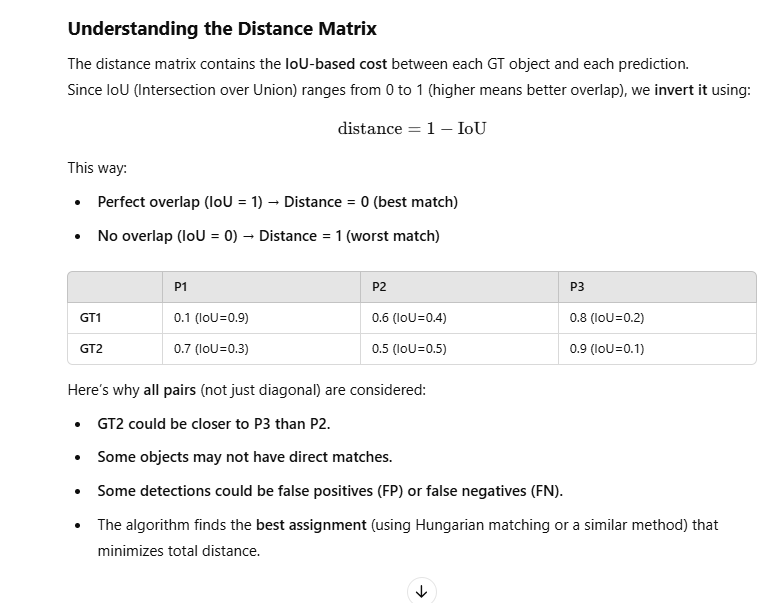

# turn into coco format for mAP:

In [10]:
import json
from pathlib import Path

# Load your original JSON
with open("/content/drive/MyDrive/mini project BIRDS/annotations/gt_desert_annotations.json") as f:
    data = json.load(f)

# COCO template
coco_gt = {
    "info": {},  # Add the 'info' key
    "licenses": [], # Add the 'licenses' key
    "images": [],
    "annotations": [],
    "categories": [{"id": 0, "name": "Bird"}]  # Add all classes here
}

# Convert each frame
for frame in data:  # Assuming `data` is a list of frames
    image_id = frame["frame_number"]
    coco_gt["images"].append({
        "id": image_id,
        "file_name": f"frame_{image_id:04d}.jpg",  # Match frame names
        "width": 1920,  # Set your video width
        "height": 1080,  # Set your video height
    })

    for obj in frame["objects"]:
        x1, y1, x2, y2 = obj["bbox"]["x1"], obj["bbox"]["y1"], obj["bbox"]["x2"], obj["bbox"]["y2"]
        coco_gt["annotations"].append({
            "id": len(coco_gt["annotations"]),  # Unique ID per annotation
            "image_id": image_id,
            "category_id": obj["class_id"],
            "bbox": [x1, y1, x2 - x1, y2 - y1],  # COCO: [x, y, width, height]
            "area": (x2 - x1) * (y2 - y1),
            "iscrowd": 0,
        })

# Save COCO JSON
with open("coco_gt.json", "w") as f:
    json.dump(coco_gt, f)

In [6]:
def coco_preds(pred_file):
  coco_list=[]
  for frame in pred_file:
    for obj in frame["objects"]:
        x1, y1, x2, y2 = obj["bbox"]["x1"], obj["bbox"]["y1"], obj["bbox"]["x2"], obj["bbox"]["y2"]
        coco_list.append({
            "image_id": frame["frame_number"],
            "category_id": 0, #because it detected birds only
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": obj["confidence"],  # Critical for mAP calculation
        })
  return coco_list

In [7]:
import json
# Load YOLO predictions
with open("/content/drive/MyDrive/mini project BIRDS/annotations/desert_annotations_bot.json") as f:
    bot_data = json.load(f)

coco_bot=coco_preds(bot_data)
with open("coco_bot.json", "w") as f:
    json.dump(coco_bot, f)

with open("/content/drive/MyDrive/mini project BIRDS/annotations/desert_annotations_byte.json") as f:
    byte_data = json.load(f)

coco_byte=coco_preds(byte_data)
with open("coco_byte.json", "w") as f:
    json.dump(coco_byte, f)

with open("/content/drive/MyDrive/mini project BIRDS/annotations/desert_pred_ds.json") as f:
  ds_data=json.load(f)

coco_ds=coco_preds(ds_data)
with open("coco_ds.json", "w") as f:
  json.dump(coco_ds, f)

with open("/content/drive/MyDrive/mini project BIRDS/annotations/sort_desert_annotations.json") as f:
  sort_data=json.load(f)

coco_sort=coco_preds(sort_data)
with open("coco_sort.json", "w") as f:
  json.dump(coco_sort, f)

In [11]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
def generate_mot(coco_json):
  coco_gt = COCO("coco_gt.json")
  coco_pred=coco_gt.loadRes(coco_json)
  # Evaluate
  # Use the coco_pred object (which is a COCO object loaded with predictions)
  # as the second argument to COCOeval
  coco_eval = COCOeval(coco_gt, coco_pred, "bbox")
  coco_eval.evaluate()
  coco_eval.accumulate()
  coco_eval.summarize()

### example usage

In [12]:
# Load ground truth and predictions
generate_mot("coco_bot.json")
  # Prints mAP scores

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.662
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.940
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.734
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.749
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.663
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.331
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.771
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [13]:
generate_mot("coco_byte.json")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.17s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.918
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.951
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.937
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.392
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.919
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.414
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.949
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [14]:
generate_mot("coco_ds.json")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.28s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.974
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.974
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.974
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.432
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.999
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [15]:
generate_mot("coco_sort.json")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.25s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.641
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.928
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.716
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.643
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.328
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet